In [1]:
import numpy as np

# Step 1: Create a 5x5 matrix of ones
matrix = np.ones((5, 5), dtype=int)

# Step 2: Set the interior (rows 1 to 3, cols 1 to 3) to zero
matrix[1:-1, 1:-1] = 0

print(matrix)


[[1 1 1 1 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 1 1 1 1]]


In [2]:
np.random.seed(42)
random_data = np.random.randn(100, 3)

# Step 1: Calculate mean and std for each column
mean = random_data.mean(axis=0)
std = random_data.std(axis=0)

# Step 2: Normalize (subtract mean, divide by std)
normalized_data = (random_data - mean) / std

# Step 3: Check results
print("Means after normalization:", normalized_data.mean(axis=0))
print("Stds after normalization:", normalized_data.std(axis=0))


Means after normalization: [-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
Stds after normalization: [1. 1. 1.]


In [3]:
# Step 1: Generate data
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# Step 2: Apply normal equation
XTX = X.T @ X
XTy = X.T @ y
theta_hat = np.linalg.inv(XTX) @ XTy

# Step 3: Print results
print("Estimated coefficients:", theta_hat)
print("True coefficients:", true_theta)


Estimated coefficients: [ 2.51723721 -1.19783796  3.72399266]
True coefficients: [ 2.5 -1.2  3.7]


In [9]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math'
        , 'Physics', 'Biology'], n_students ),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration
print(df.head())        # Shows the first 5 rows
print(df.info())        # Shows column names, data types, and non-null counts
print(df.describe())    # Shows summary statistics (mean, std, min, max)
print(df.isnull().sum())
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

# Task 2: Analysis

avg_scores = df.groupby('major')['exam_score'].mean()
print("Average exam score by major:")
print(avg_scores)


best_major = avg_scores.idxmax()
print("Major with highest average exam score:", best_major)

correlation = df['hours_studied'].corr(df['exam_score'])
print("Correlation between hours studied and exam score:", correlation)

def categorize(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize)

print(df[['student_id','exam_score','performance']].head())

# Task 3: Advanced Analysis
summary = df.groupby(['major','year']).agg(
    num_students=('student_id','count'),
    avg_exam_score=('exam_score','mean'),
    avg_hours_studied=('hours_studied','mean')
)

print(summary)

top_students = df.sort_values(by='exam_score', ascending=False).head(5)
print(top_students[['student_id','exam_score','major','year']])

pivot = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print(pivot)








   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                      2      14.042336
4        1004  Physics     4   93.657745                      6      15.287370
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes

/tmp/ipykernel_13519/1709797508.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='major', y='exam_score', data=df, ax=axes[1], palette='Set2')


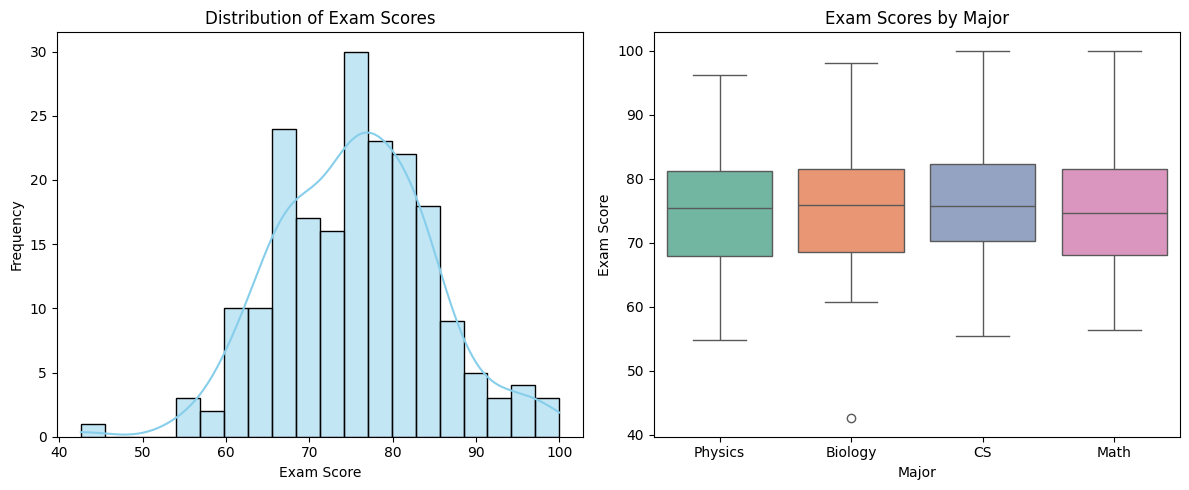

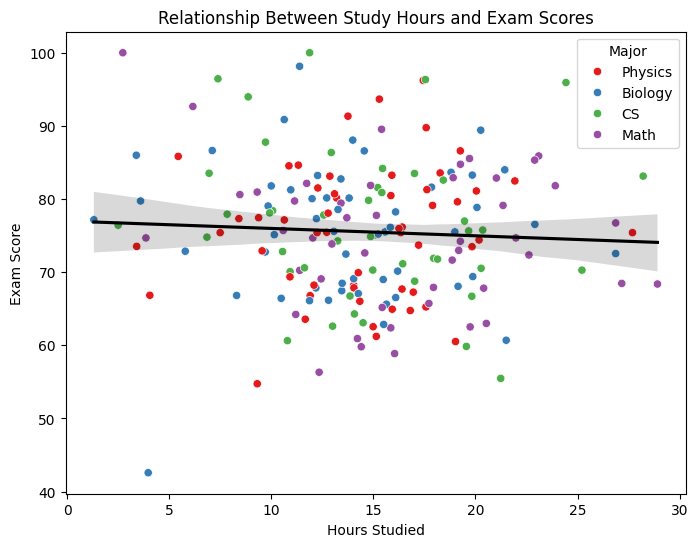

/tmp/ipykernel_13519/1709797508.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='major', y='exam_score', data=avg_scores, ax=axes[0,0], palette='Set2')
/tmp/ipykernel_13519/1709797508.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year', data=df, ax=axes[0,1], palette='Set3')
/tmp/ipykernel_13519/1709797508.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='performance', y='exam_score', data=df, ax=axes[1,1], palette='muted')


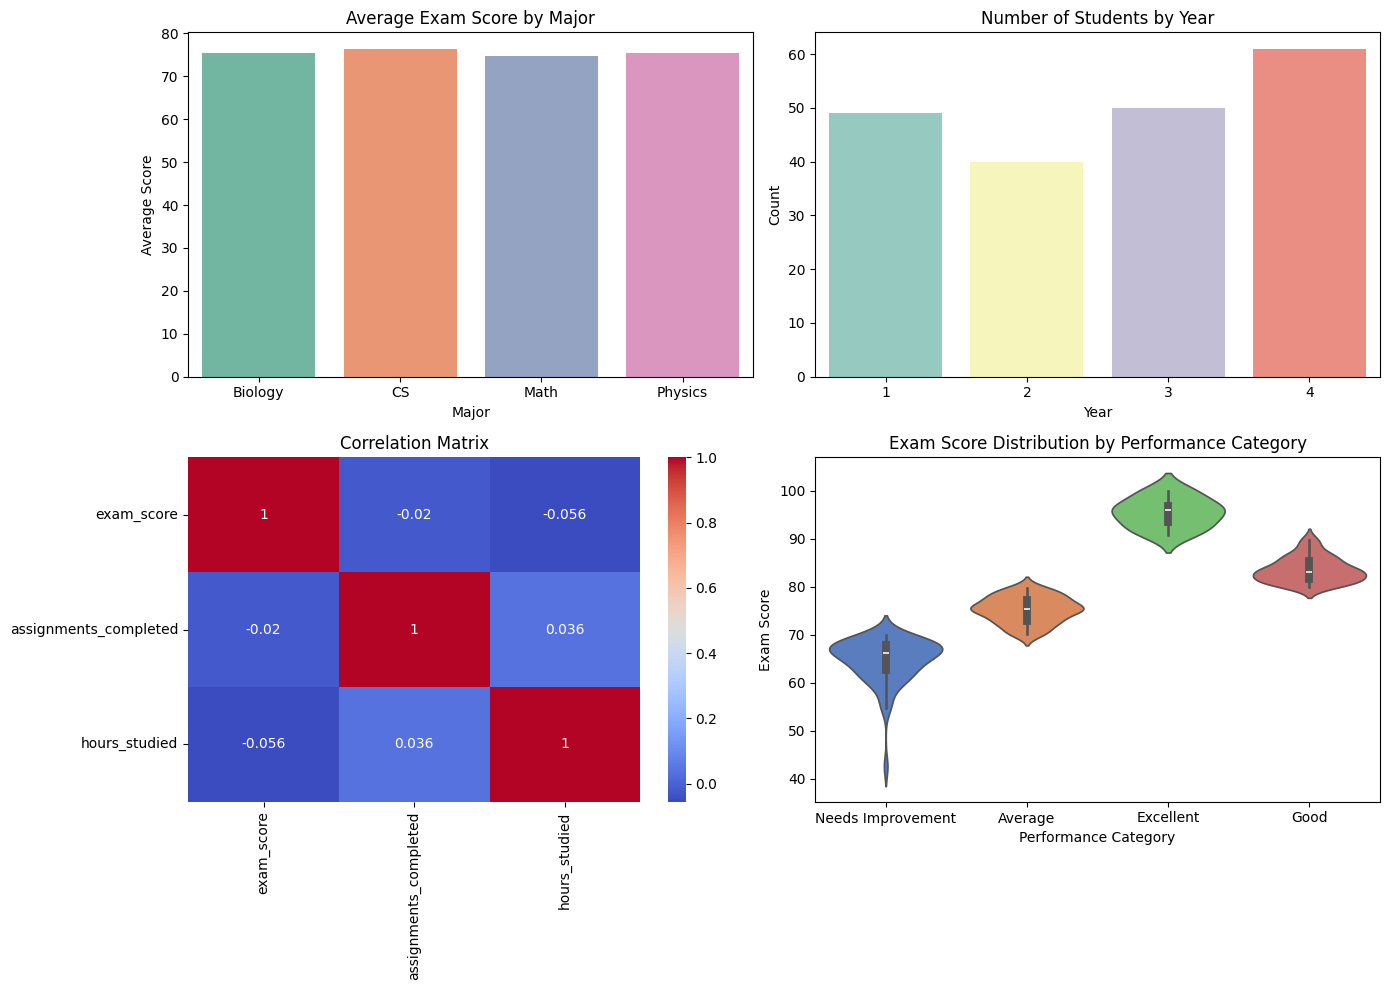

In [10]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns
# Task 1: Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['exam_score'], kde=True, bins=20, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Frequency")

sns.boxplot(x='major', y='exam_score', data=df, ax=axes[1], palette='Set2')
axes[1].set_title("Exam Scores by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

# Task 2: Relationship Visualization

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major',        # Color points by major
    palette='Set1'
)

sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False,      # Only show the line, not extra points
    color='black'
)

plt.title("Relationship Between Study Hours and Exam Scores")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Major")
plt.show()

# Task 3: Advanced Dashboard

fig, axes = plt.subplots(2, 2, figsize=(14, 10))


avg_scores = df.groupby('major')['exam_score'].mean().reset_index()
sns.barplot(x='major', y='exam_score', data=avg_scores, ax=axes[0,0], palette='Set2')
axes[0,0].set_title("Average Exam Score by Major")
axes[0,0].set_xlabel("Major")
axes[0,0].set_ylabel("Average Score")

sns.countplot(x='year', data=df, ax=axes[0,1], palette='Set3')
axes[0,1].set_title("Number of Students by Year")
axes[0,1].set_xlabel("Year")
axes[0,1].set_ylabel("Count")

corr = df[['exam_score','assignments_completed','hours_studied']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,0])
axes[1,0].set_title("Correlation Matrix")

sns.violinplot(x='performance', y='exam_score', data=df, ax=axes[1,1], palette='muted')
axes[1,1].set_title("Exam Score Distribution by Performance Category")
axes[1,1].set_xlabel("Performance Category")
axes[1,1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()







   customer_id  purchase_frequency  avg_purchase_value  churn_risk         CLV
0            1                  10                  50    0.333333  666.666667
1            2                   5                  40    0.666667  333.333333
2            3                  15                  60    0.000000  900.000000
   age age_group
0   22     18-25
1   30     26-35
2   45     36-50
3   55     51-70
4   68     51-70
     age        income  purchase_frequency  avg_purchase_value          CLV
426   42  68713.567863                   8          154.285448  1645.711441
213   41  45580.608009                   7          164.920221  1635.458860
410   44  49344.934596                   6          177.097211  1593.874900
194   44  57331.964922                   6          176.640590  1589.765308
244   28  29255.076913                   7          159.784979  1584.534373
423   43  34443.666248                   6          173.245130  1559.206172
386   63  24200.782005                   9        

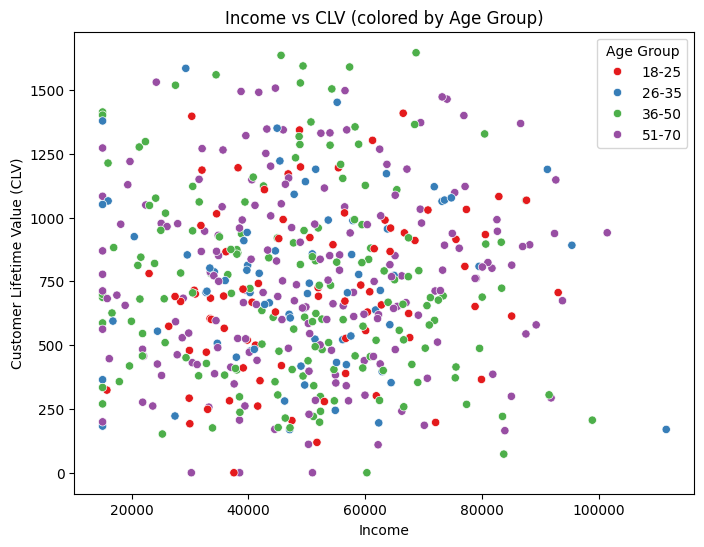

/tmp/ipykernel_838/3467634026.py:123: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv_age = customers.groupby('age_group')['CLV'].mean().reset_index()
/tmp/ipykernel_838/3467634026.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='CLV', data=avg_clv_age, palette='Set2')


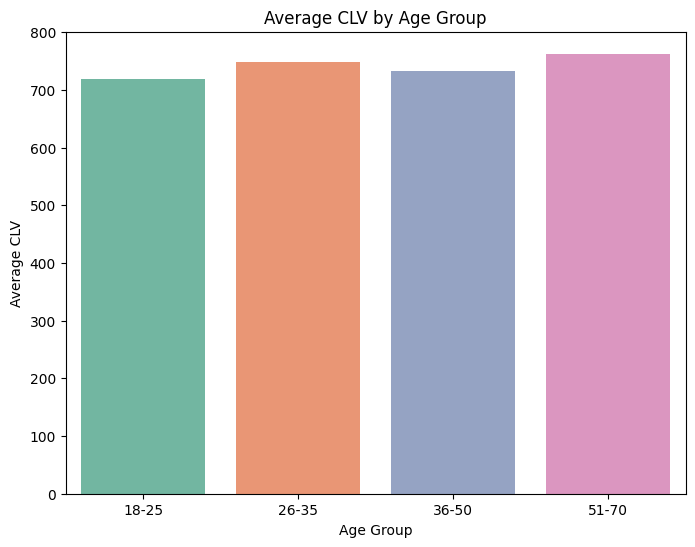

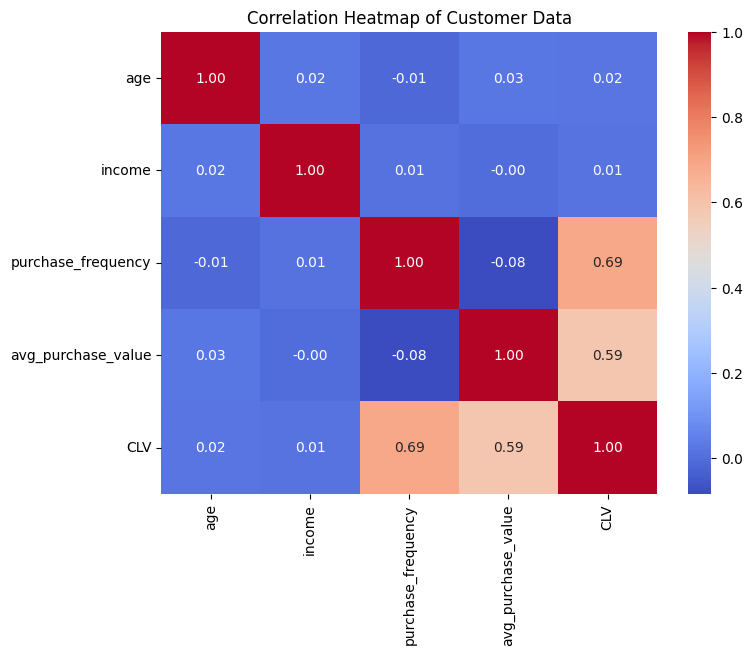

In [4]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

np.random.seed(42)
n_customers = 500


#Calculate customer lifetime value (CLV)
import pandas as pd

# Example data
df = pd.DataFrame({
    'customer_id': [1, 2, 3],
    'purchase_frequency': [10, 5, 15],
    'avg_purchase_value': [50, 40, 60]
})

# Maximum purchase frequency across all customers
max_frequency = df['purchase_frequency'].max()

# Calculate churn risk
df['churn_risk'] = 1 - (
    df['purchase_frequency'] / max_frequency
)

# Calculate CLV
df['CLV'] = (
    df['purchase_frequency']
    * df['avg_purchase_value']
    * (1 + df['churn_risk'])
)

print(df)


#Create age groups: 18-25, 26-35, 36-50, 51-70

# Example DataFrame
df = pd.DataFrame({
    'age': [22, 30, 45, 55, 68]
})

# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70'],
    include_lowest=True
)

print(df)

# Step 1: Find max purchase frequency
max_freq = customers['purchase_frequency'].max()

# Step 2: Calculate churn risk
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_freq)

# Step 3: Calculate CLV
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])



# Identify top 10% of customers by CLV
top_10_percent = customers.sort_values(by='CLV', ascending=False).head(int(0.10 * len(customers)))
print(top_10_percent[['age','income','purchase_frequency','avg_purchase_value','CLV']])


#Create visualizations:
import matplotlib.pyplot as plt
import seaborn as sns

customers['age_group'] = pd.cut(
    customers['age'],
    bins=[18, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70'],
    include_lowest=True
)


#Scatter plot of income vs CLV.
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group',
    palette='Set1'
)
plt.title("Income vs CLV (colored by Age Group)")
plt.xlabel("Income")
plt.ylabel("Customer Lifetime Value (CLV)")
plt.legend(title="Age Group")
plt.show()
#Bar chart of average CLV by age group.

avg_clv_age = customers.groupby('age_group')['CLV'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(x='age_group', y='CLV', data=avg_clv_age, palette='Set2')
plt.title("Average CLV by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average CLV")
plt.show()


#Correlation heatmap.
corr = customers[['age','income','purchase_frequency','avg_purchase_value','CLV']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Customer Data")
plt.show()





Analysis and Recommendations

Customer data set offers useful information on customers' buying patterns and about customer value. Income and Purchase frequency are the two strongest factors of Customer Lifetime Value (CLV) and have a positive correlation, this means that the higher the income of the customer, the higher the value of CLV and the more often he purchases, the higher the value of CLV. There is some difference in the results by age groups, where older age groups (36-70) tend to have more stable buying habits, and younger (18-25 and 26-35) age groups have more variable buying habits. The correlation heatmap indicates that purchase frequency and average purchase value are the top two factors influencing the average CLV, with the bar chart showing that this average CLV increases as customers get older. From these results, the company should implement a better retention system for high income, high frequency customers to generate recurring revenue and devise incentives for younger customers to continue to buy products and services. It is a compromise that helps to build brand loyalty in the long term while still generating short-term sales.